# Load SmartSPIM Dataset with Mask at Scale 1

Configure the dataset parameters for SmartSPIM_649103_2023-07-10_19-47-40

In [1]:
from aind_octo_data_loaders.multiscale_masked_dataloader import MultiScaleMaskedDataset

# Dataset configuration
sample_id = "SmartSPIM_649103_2023-07-10_19-47-40_stitched_2023-08-23_01-29-58"
prefix = "image_tile_fusing/OMEZarr"
channels = [
    "Ex_488_Em_525.zarr",
    "Ex_561_Em_600.zarr", 
    "Ex_647_Em_690.zarr"
]

# Choose a channel to load (let's use the first one)
channel = channels[0]  # Ex_488_Em_525.zarr

# Construct the zarr file path
# Assuming S3 bucket structure: s3://bucket-name/sample_id/prefix/channel
zarr_file = f"s3://aind-open-data/{sample_id}/{prefix}/{channel}"

# Mask file path
mask_file = f"s3://aind-msma-morphology-data/test_data/SmartSPIM/smartspim_segmentation_masks/SmartSPIM_{sample_id.split('_')[1]}/segmentation_mask.zarr"

print(f"Zarr file: {zarr_file}")
print(f"Mask file: {mask_file}")

Zarr file: s3://aind-open-data/SmartSPIM_649103_2023-07-10_19-47-40_stitched_2023-08-23_01-29-58/image_tile_fusing/OMEZarr/Ex_488_Em_525.zarr
Mask file: s3://aind-msma-morphology-data/test_data/SmartSPIM/smartspim_segmentation_masks/SmartSPIM_649103/segmentation_mask.zarr


In [2]:
# Create the MaskedZarrDataset at scale 1
dataset = MultiScaleMaskedDataset(
    sample=sample_id,
    zarr_file=zarr_file,
    mask_file=mask_file,
    scale=0,  # Scale 1 for data
    downsampled_mask_level=3, # Scale 3 for mask ROI selection
    volume_size=128,
    mask_threshold=0.5,
    do_pad_array=True,
    platform="SmartSPIM",
    block_prefilter=False,
    overlap_pct=0.0,
    pyramid_levels=[0, 1, 2],
    force_refilter=True,
    random_indices=True,
)

print(f"\nDataset loaded successfully!")
print(f"Total volumes: {len(dataset)}")
item = dataset[0]
print(f"\nSample item keys: {list(item.keys())}")
print(f"Available pyramid levels: {list(item['images'].keys())}")
print(f"Shapes of images at each level:")
for lvl, img in item["images"].items():
    print(f"  Level {lvl}: {img.shape}")
    print(f"  Level {lvl} coords: {item['coords'][lvl]}")


Dataset loaded successfully!

	Using coarse prefilter from level 3 -> scale 0
	Coarse prefilter kept 48675 coarse blocks out of 147456 total.
	48675/113988 valid indices after masking.
Total volumes: 48675
Coordinates:
  * T        (T) int64 8B 0
  * C        (C) int64 8B 0
  * Z        (Z) int64 1kB 896 897 898 899 900 901 ... 1019 1020 1021 1022 1023
  * Y        (Y) int64 1kB 8448 8449 8450 8451 8452 ... 8571 8572 8573 8574 8575
  * X        (X) int64 1kB 6656 6657 6658 6659 6660 ... 6779 6780 6781 6782 6783

Sample item keys: ['images', 'coords', 'base_coords', 'sample', 'platform', 'scale']
Available pyramid levels: [0, 1, 2]
Shapes of images at each level:
  Level 0: (128, 128, 128)
  Level 0 coords: (slice(896, 1024, None), slice(8448, 8576, None), slice(6656, 6784, None))
  Level 1: (128, 128, 128)
  Level 1 coords: (slice(416, 544, None), slice(4192, 4320, None), slice(3296, 3424, None))
  Level 2: (128, 128, 128)
  Level 2 coords: (slice(176, 304, None), slice(2064, 2192, No

In [3]:
print(f"Lazy array for level: {dataset.ms_lazy_arrays}")

Lazy array for level: {0: dask.array<getitem, shape=(3499, 8813, 7441), dtype=uint16, chunksize=(128, 128, 128), chunktype=numpy.ndarray>, 1: dask.array<getitem, shape=(1749, 4406, 3720), dtype=uint16, chunksize=(128, 128, 128), chunktype=numpy.ndarray>, 2: dask.array<getitem, shape=(874, 2203, 1860), dtype=uint16, chunksize=(128, 128, 128), chunktype=numpy.ndarray>}


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from typing import Sequence, Tuple

def draw_token_grid(ax, shape, token_size, color="cyan", alpha=0.4):
    """
    Draw token grid for visualization.
    """
    H, W = shape

    for y in range(0, H, token_size):
        ax.plot([0, W], [y, y], color=color, alpha=alpha, linewidth=0.5)

    for x in range(0, W, token_size):
        ax.plot([x, x], [0, H], color=color, alpha=alpha, linewidth=0.5)


def _centered_context_slice(center: int, target: int, arr_size: int) -> slice:
    """Return a slice of length `target` centered on `center`, clamped to [0, arr_size)."""
    start = max(0, center - target // 2)
    end = start + target
    if end > arr_size:
        end = arr_size
        start = max(0, arr_size - target)
    return slice(start, end)

def _downscale_slice(s: slice, factor: int) -> slice:
    """
    Downscale a slice by a factor,
    adjusting the start and stop accordingly.
    """
    if s.start is None or s.stop is None:
        raise ValueError("Scaling requires explicit start and stop in slices.")
    return slice(int(s.start / factor), int(s.stop / factor))


def _scale_slices(slices: Sequence[slice], factors: Sequence[int]) -> Tuple[slice, slice, slice]:
    """
    Scale a sequence of slices by corresponding factors.
    """
    return tuple(_downscale_slice(s, f) for s, f in zip(slices, factors))  # type: ignore[return-value]


def show_multiscale_overlap(
    images,
    coords,
    scale_factors,
    base_coords,
    token_size=16
):
    """
    Visualize patches across pyramid levels.
    """

    levels = sorted(images.keys())
    base_level = levels[0]
    n_levels = len(levels)
    AXIS_NAMES = ["Z", "Y", "X"]

    fig, axes = plt.subplots(1, n_levels, figsize=(6 * n_levels, 12))
    img_coordinates = []
    if n_levels == 1:
        axes = [axes]

    for i, lvl in enumerate(levels):
        img_coordinates.append(coords[lvl])
        ax = axes[i]
        img = images[lvl]
        # mip = np.max(img, axis=0)
        mip = img[img.shape[0] // 2]  # Middle slice for visualization
        plow, phigh = np.percentile(mip, [1, 99])
        ax.imshow(mip, cmap="gray", vmin=plow, vmax=phigh)
        draw_token_grid(ax, mip.shape, token_size)
        coords_print = ""
        for i, slc in enumerate(coords[lvl]):
            coords_print += f" {AXIS_NAMES[i]}={slc.start}:{slc.stop} "

        if lvl == base_level:
            ax.set_title(f"Level {lvl}  (highest-res)\nshape={img.shape}\ncoords={coords_print}")
        else:
            # Compute the HR patch location *within* the context patch.
            # `coords[lvl]` is the context slice; `base_coords` scaled gives
            # the inner HR region in this level's coordinates.
            factors = scale_factors[lvl]
            hr_coords = _scale_slices(base_coords, factors)
            ctx_z, ctx_y, ctx_x = coords[lvl]
            hr_z, hr_y, hr_x = hr_coords

            hr_coords_print = f"Z={hr_z.start}:{hr_z.stop} Y={hr_y.start}:{hr_y.stop} X={hr_x.start}:{hr_x.stop}"

            print("Context ZYX: ", ctx_z, ctx_y, ctx_x)
            print("HR ZYX: ", hr_z, hr_y, hr_x)

            box_y0 = hr_y.start - ctx_y.start
            box_x0 = hr_x.start - ctx_x.start
            box_h = hr_y.stop - hr_y.start
            box_w = hr_x.stop - hr_x.start

            rect_fill = Rectangle(
                (box_x0, box_y0), box_w, box_h,
                linewidth=0, edgecolor="none",
                facecolor="red", alpha=0.25,
            )
            rect_edge = Rectangle(
                (box_x0, box_y0), box_w, box_h,
                linewidth=2, edgecolor="red",
                facecolor="none", label="HR patch",
            )
            ax.add_patch(rect_fill)
            ax.add_patch(rect_edge)
            ax.legend(loc="upper right", fontsize=7, framealpha=0.6)
            ax.set_title(f"Level {lvl}  (context)\nshape={img.shape}\ncoords={coords_print}\nHR coords={hr_coords_print}\nHR box={box_h}x{box_w}")

        ax.set_axis_off()

    fig.suptitle(
        "Multiscale Alignment\nRed box = High-Res patch location | Cyan = Token Grid",
        fontsize=14
    )

    plt.tight_layout()
    # plt.savefig("multiscale_overlap.png", dpi=200)
    # plt.close()
    plt.show()
    return img_coordinates


Coordinates:
  * T        (T) int64 8B 0
  * C        (C) int64 8B 0
  * Z        (Z) int64 1kB 768 769 770 771 772 773 ... 890 891 892 893 894 895
  * Y        (Y) int64 1kB 4480 4481 4482 4483 4484 ... 4603 4604 4605 4606 4607
  * X        (X) int64 1kB 4096 4097 4098 4099 4100 ... 4219 4220 4221 4222 4223
Context ZYX:  slice(352, 480, None) slice(2208, 2336, None) slice(2016, 2144, None)
HR ZYX:  slice(384, 448, None) slice(2240, 2304, None) slice(2048, 2112, None)
Context ZYX:  slice(144, 272, None) slice(1072, 1200, None) slice(976, 1104, None)
HR ZYX:  slice(192, 224, None) slice(1120, 1152, None) slice(1024, 1056, None)


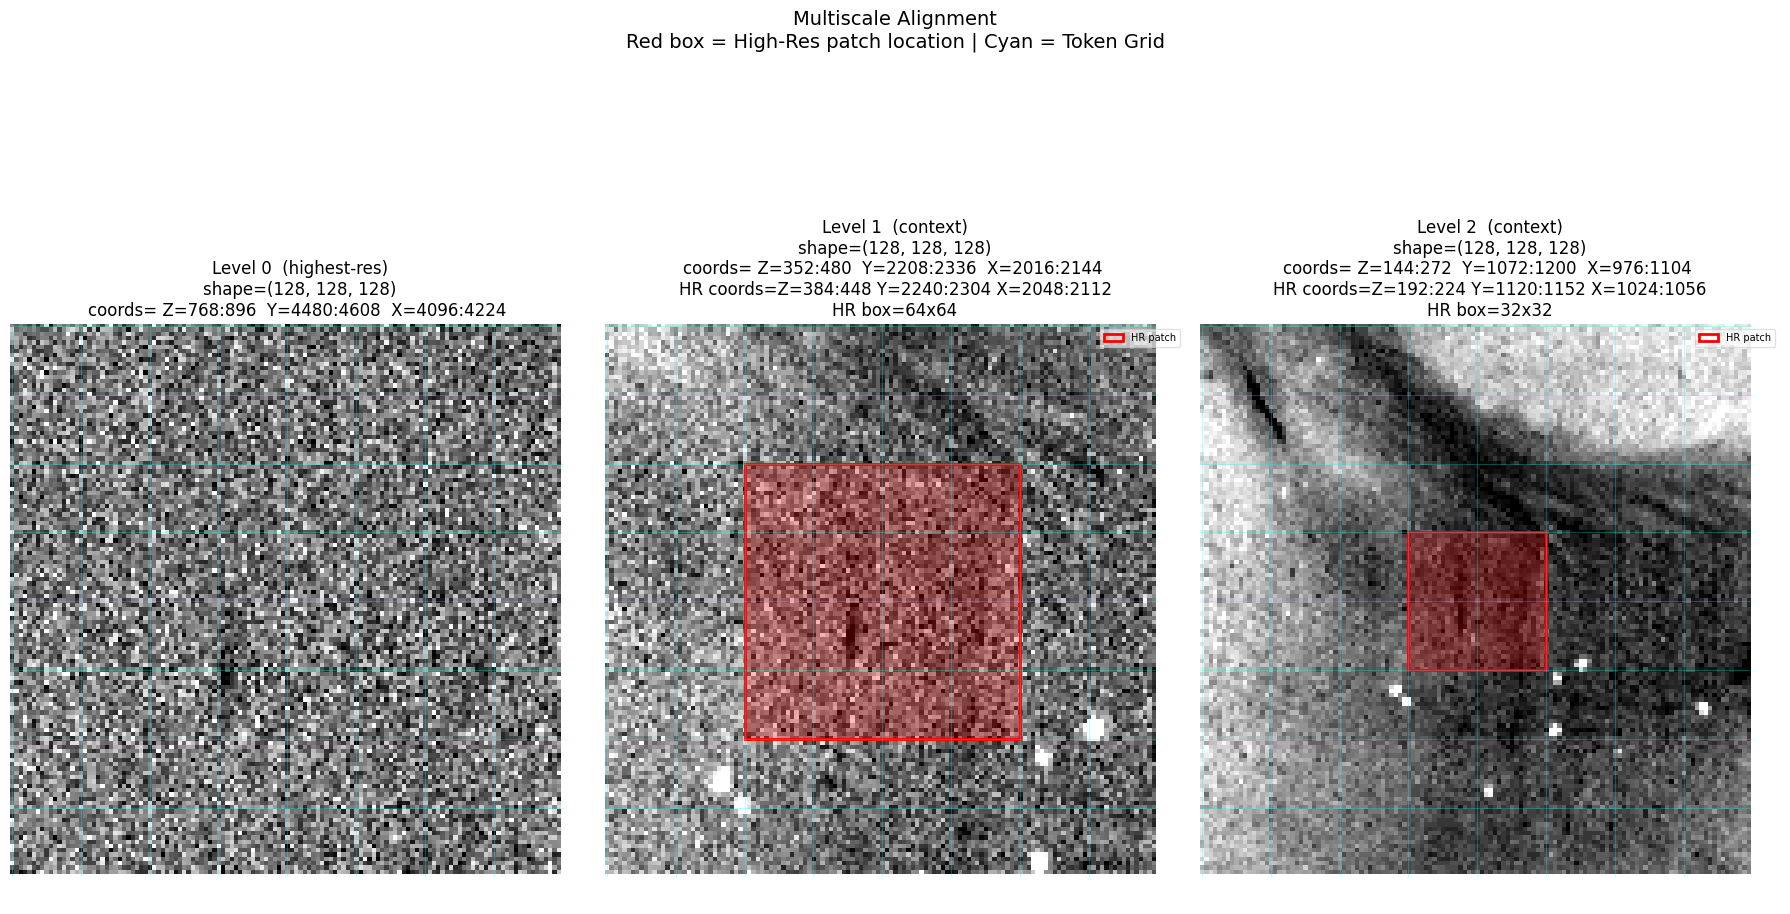

Coordinates:
  * T        (T) int64 8B 0
  * C        (C) int64 8B 0
  * Z        (Z) int64 1kB 2048 2049 2050 2051 2052 ... 2171 2172 2173 2174 2175
  * Y        (Y) int64 1kB 7552 7553 7554 7555 7556 ... 7675 7676 7677 7678 7679
  * X        (X) int64 1kB 7040 7041 7042 7043 7044 ... 7163 7164 7165 7166 7167
Context ZYX:  slice(992, 1120, None) slice(3744, 3872, None) slice(3488, 3616, None)
HR ZYX:  slice(1024, 1088, None) slice(3776, 3840, None) slice(3520, 3584, None)
Context ZYX:  slice(464, 592, None) slice(1840, 1968, None) slice(1712, 1840, None)
HR ZYX:  slice(512, 544, None) slice(1888, 1920, None) slice(1760, 1792, None)


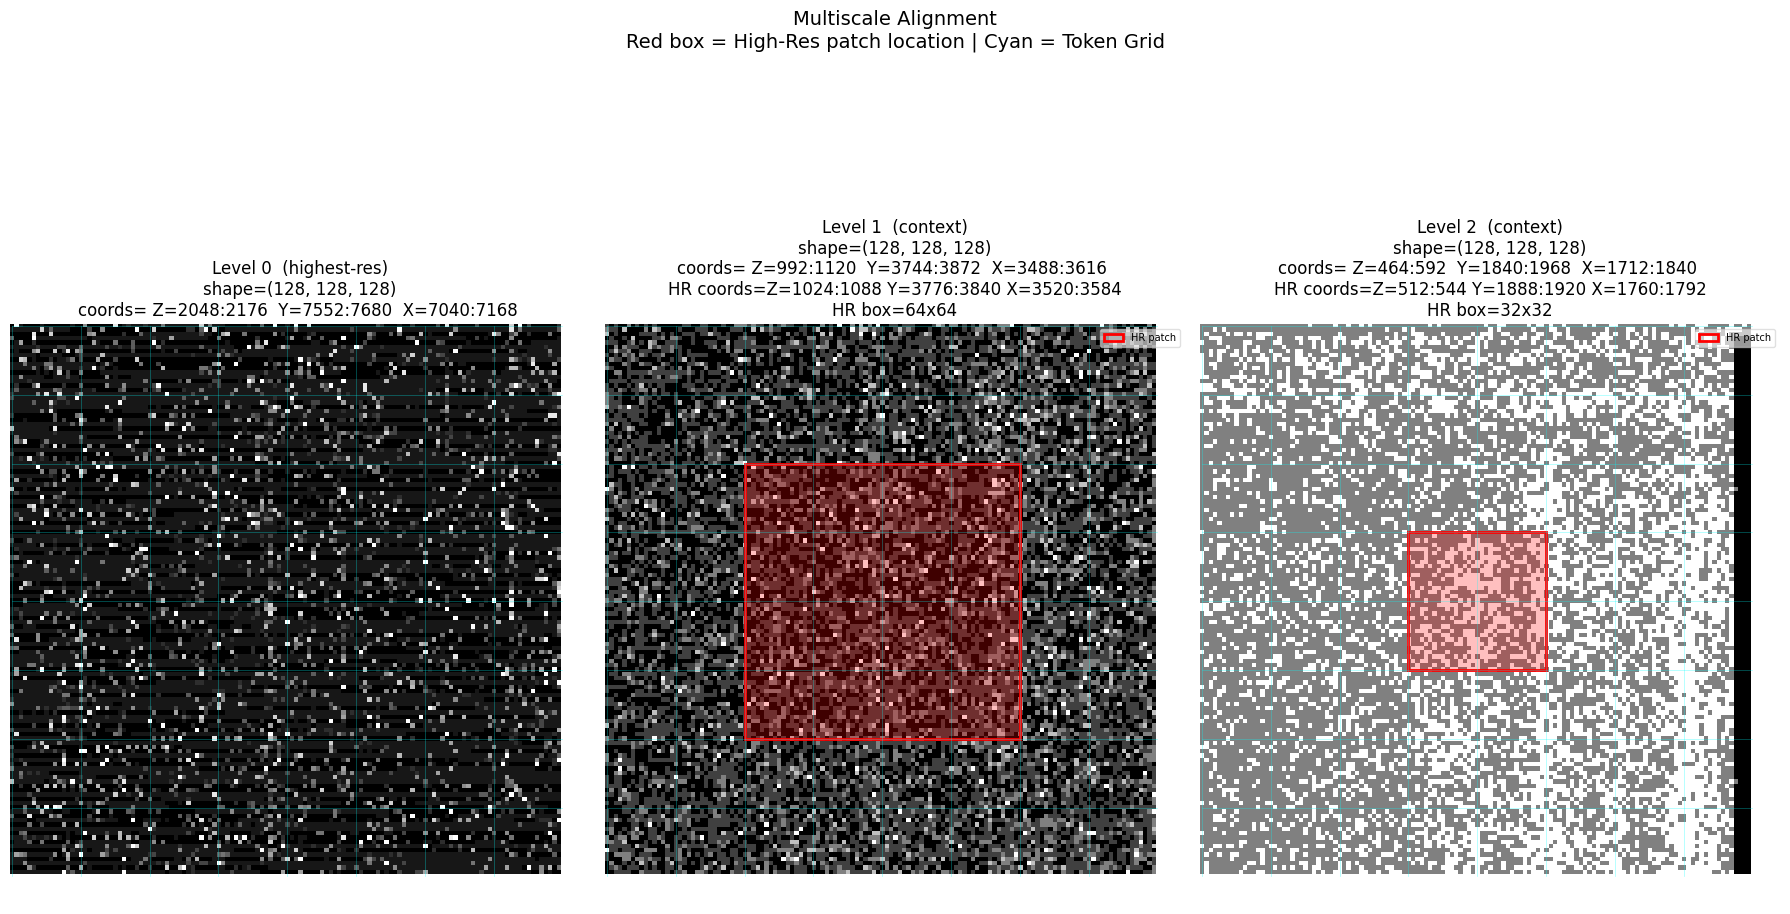

Coordinates:
  * T        (T) int64 8B 0
  * C        (C) int64 8B 0
  * Z        (Z) int64 1kB 2048 2049 2050 2051 2052 ... 2171 2172 2173 2174 2175
  * Y        (Y) int64 1kB 2048 2049 2050 2051 2052 ... 2171 2172 2173 2174 2175
  * X        (X) int64 1kB 6528 6529 6530 6531 6532 ... 6651 6652 6653 6654 6655
Context ZYX:  slice(992, 1120, None) slice(992, 1120, None) slice(3232, 3360, None)
HR ZYX:  slice(1024, 1088, None) slice(1024, 1088, None) slice(3264, 3328, None)
Context ZYX:  slice(464, 592, None) slice(464, 592, None) slice(1584, 1712, None)
HR ZYX:  slice(512, 544, None) slice(512, 544, None) slice(1632, 1664, None)


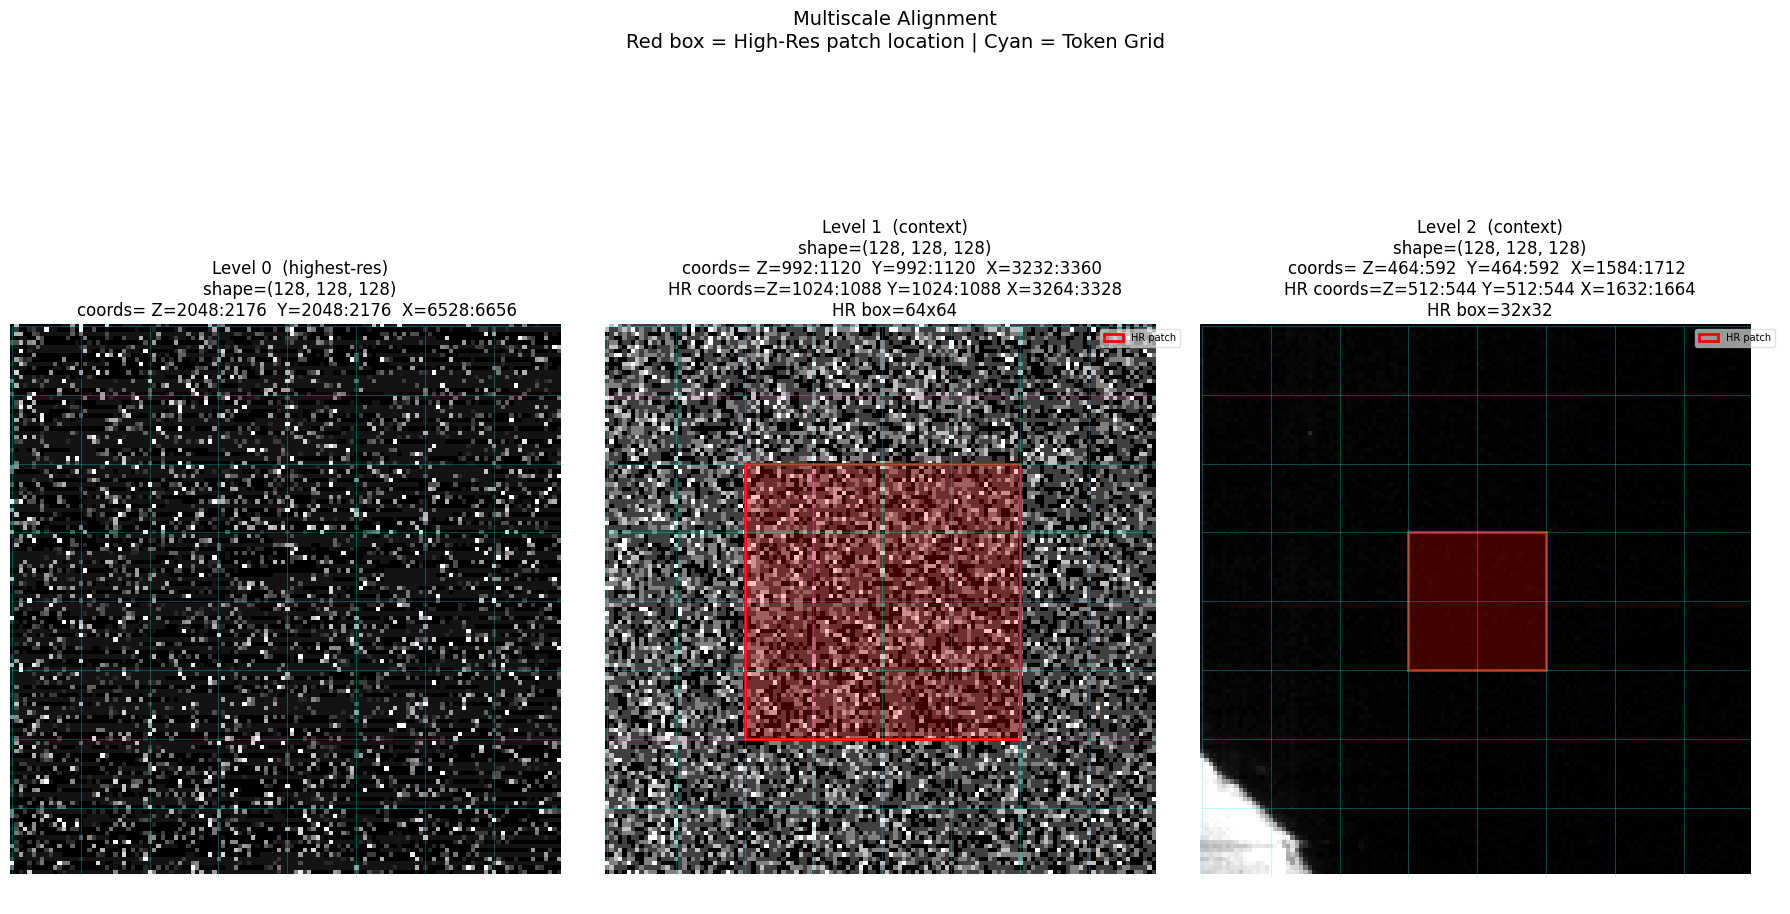

Coordinates:
  * T        (T) int64 8B 0
  * C        (C) int64 8B 0
  * Z        (Z) int64 1kB 896 897 898 899 900 901 ... 1019 1020 1021 1022 1023
  * Y        (Y) int64 1kB 2176 2177 2178 2179 2180 ... 2299 2300 2301 2302 2303
  * X        (X) int64 1kB 2048 2049 2050 2051 2052 ... 2171 2172 2173 2174 2175
Context ZYX:  slice(416, 544, None) slice(1056, 1184, None) slice(992, 1120, None)
HR ZYX:  slice(448, 512, None) slice(1088, 1152, None) slice(1024, 1088, None)
Context ZYX:  slice(176, 304, None) slice(496, 624, None) slice(464, 592, None)
HR ZYX:  slice(224, 256, None) slice(544, 576, None) slice(512, 544, None)


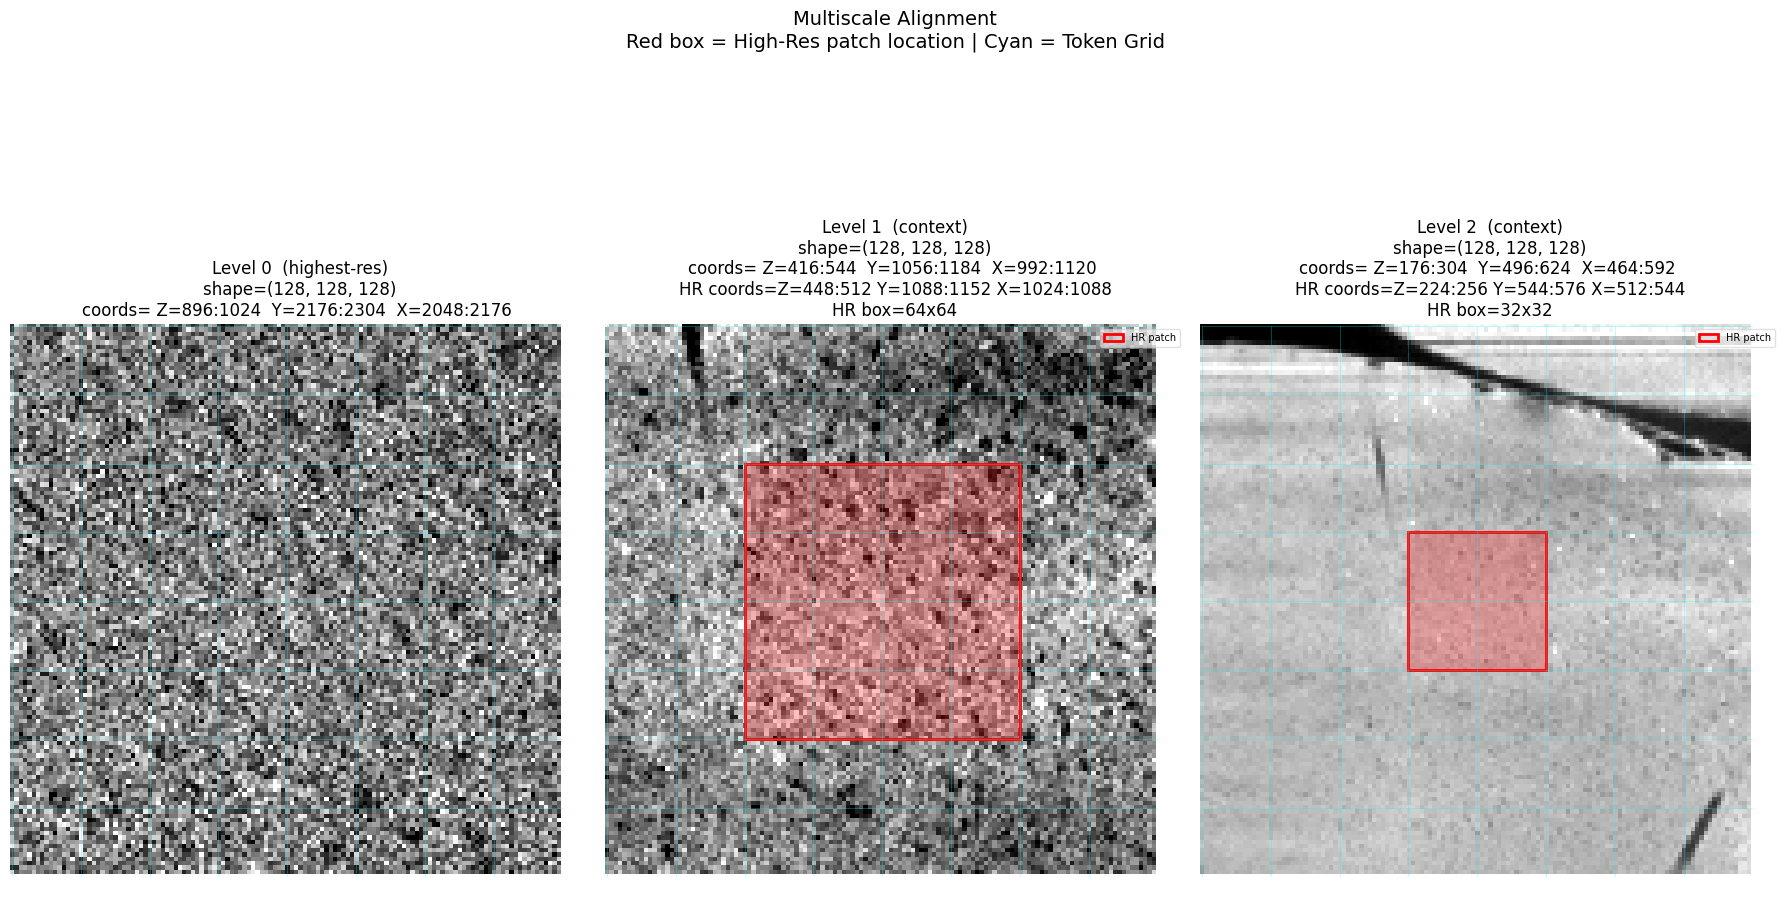

Coordinates:
  * T        (T) int64 8B 0
  * C        (C) int64 8B 0
  * Z        (Z) int64 1kB 0 1 2 3 4 5 6 7 8 ... 120 121 122 123 124 125 126 127
  * Y        (Y) int64 1kB 128 129 130 131 132 133 ... 250 251 252 253 254 255
  * X        (X) int64 1kB 6272 6273 6274 6275 6276 ... 6395 6396 6397 6398 6399
Context ZYX:  slice(0, 128, None) slice(32, 160, None) slice(3104, 3232, None)
HR ZYX:  slice(0, 64, None) slice(64, 128, None) slice(3136, 3200, None)
Context ZYX:  slice(0, 128, None) slice(0, 128, None) slice(1520, 1648, None)
HR ZYX:  slice(0, 32, None) slice(32, 64, None) slice(1568, 1600, None)


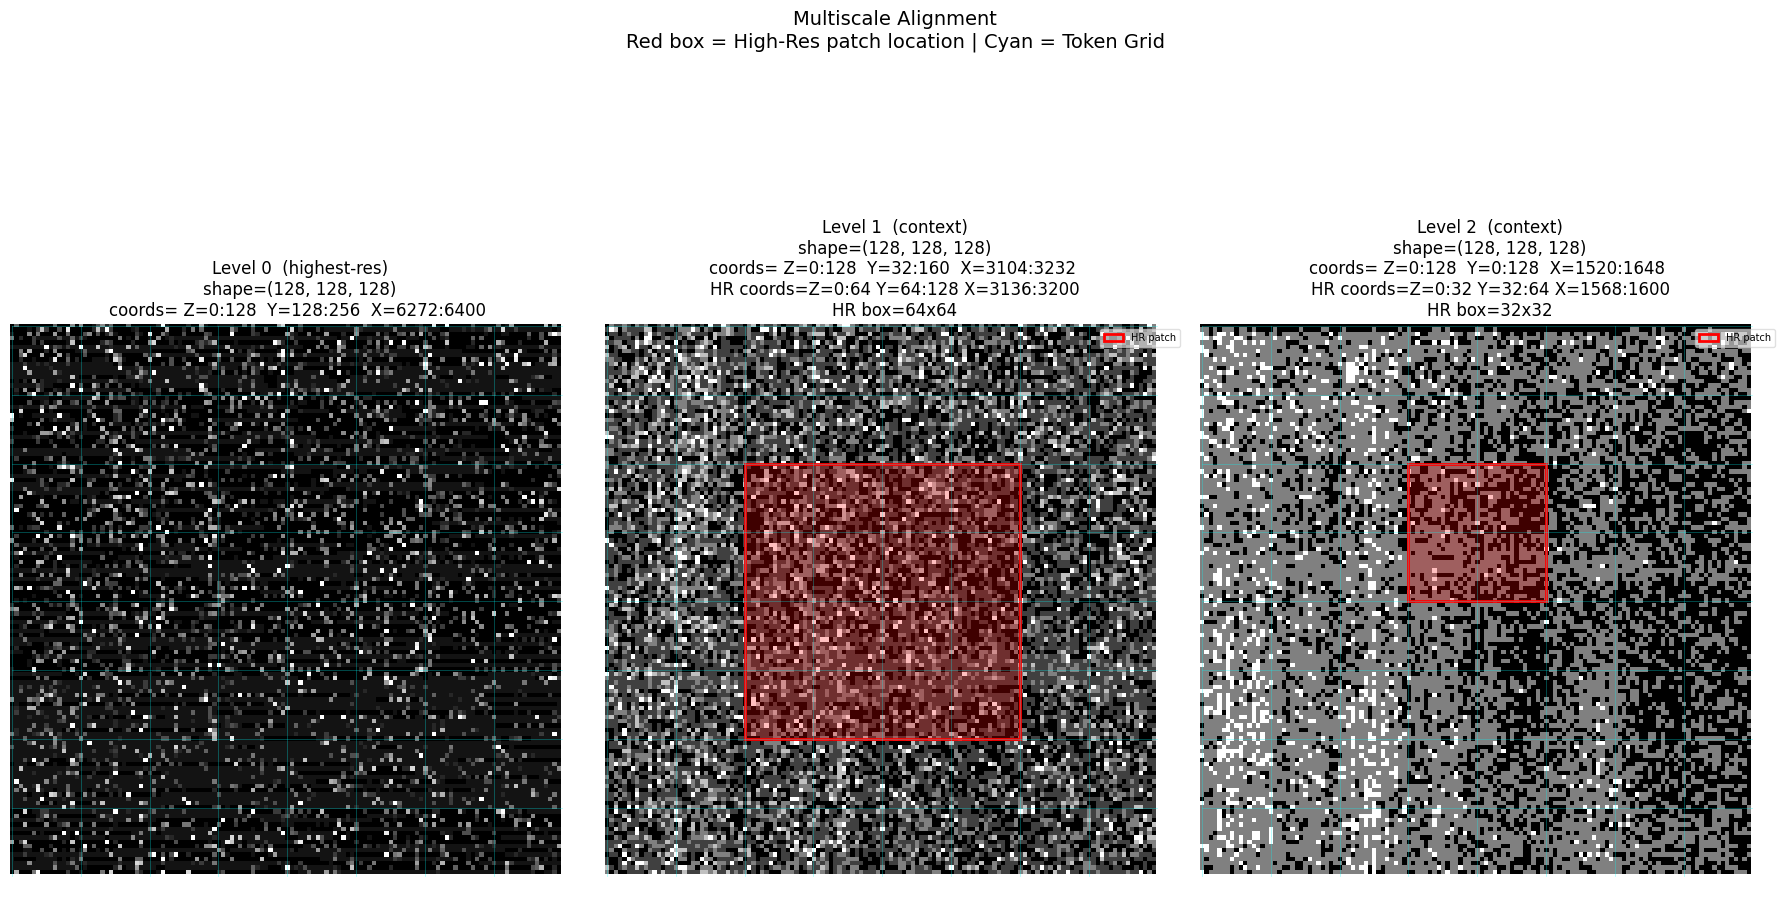

In [5]:
%matplotlib inline
plot_n_images = 5

total_coords = []
for i in range(min(plot_n_images, len(dataset))):
    item = dataset[i]
    coordinates = show_multiscale_overlap(
        images=item["images"],
        coords=item["coords"],
        scale_factors=dataset.ms_scale_factors,
        base_coords=item["base_coords"],
    )
    total_coords.append(coordinates)


Sample  0  coordinates: [(slice(768, 896, None), slice(4480, 4608, None), slice(4096, 4224, None)), (slice(352, 480, None), slice(2208, 2336, None), slice(2016, 2144, None)), (slice(144, 272, None), slice(1072, 1200, None), slice(976, 1104, None))]
Lazy array:  dask.array<getitem, shape=(3499, 8813, 7441), dtype=uint16, chunksize=(128, 128, 128), chunktype=numpy.ndarray>  leve  0
Lazy array:  dask.array<getitem, shape=(1749, 4406, 3720), dtype=uint16, chunksize=(128, 128, 128), chunktype=numpy.ndarray>  leve  1
Lazy array:  dask.array<getitem, shape=(874, 2203, 1860), dtype=uint16, chunksize=(128, 128, 128), chunktype=numpy.ndarray>  leve  2

Sample  1  coordinates: [(slice(2048, 2176, None), slice(7552, 7680, None), slice(7040, 7168, None)), (slice(992, 1120, None), slice(3744, 3872, None), slice(3488, 3616, None)), (slice(464, 592, None), slice(1840, 1968, None), slice(1712, 1840, None))]
Lazy array:  dask.array<getitem, shape=(3499, 8813, 7441), dtype=uint16, chunksize=(128, 128, 1

Lazy array:  dask.array<getitem, shape=(1749, 4406, 3720), dtype=uint16, chunksize=(128, 128, 128), chunktype=numpy.ndarray>  leve  1
Lazy array:  dask.array<getitem, shape=(874, 2203, 1860), dtype=uint16, chunksize=(128, 128, 128), chunktype=numpy.ndarray>  leve  2

Sample  2  coordinates: [(slice(2048, 2176, None), slice(2048, 2176, None), slice(6528, 6656, None)), (slice(992, 1120, None), slice(992, 1120, None), slice(3232, 3360, None)), (slice(464, 592, None), slice(464, 592, None), slice(1584, 1712, None))]
Lazy array:  dask.array<getitem, shape=(3499, 8813, 7441), dtype=uint16, chunksize=(128, 128, 128), chunktype=numpy.ndarray>  leve  0
Lazy array:  dask.array<getitem, shape=(1749, 4406, 3720), dtype=uint16, chunksize=(128, 128, 128), chunktype=numpy.ndarray>  leve  1
Lazy array:  dask.array<getitem, shape=(874, 2203, 1860), dtype=uint16, chunksize=(128, 128, 128), chunktype=numpy.ndarray>  leve  2

Sample  3  coordinates: [(slice(896, 1024, None), slice(2176, 2304, None), slice

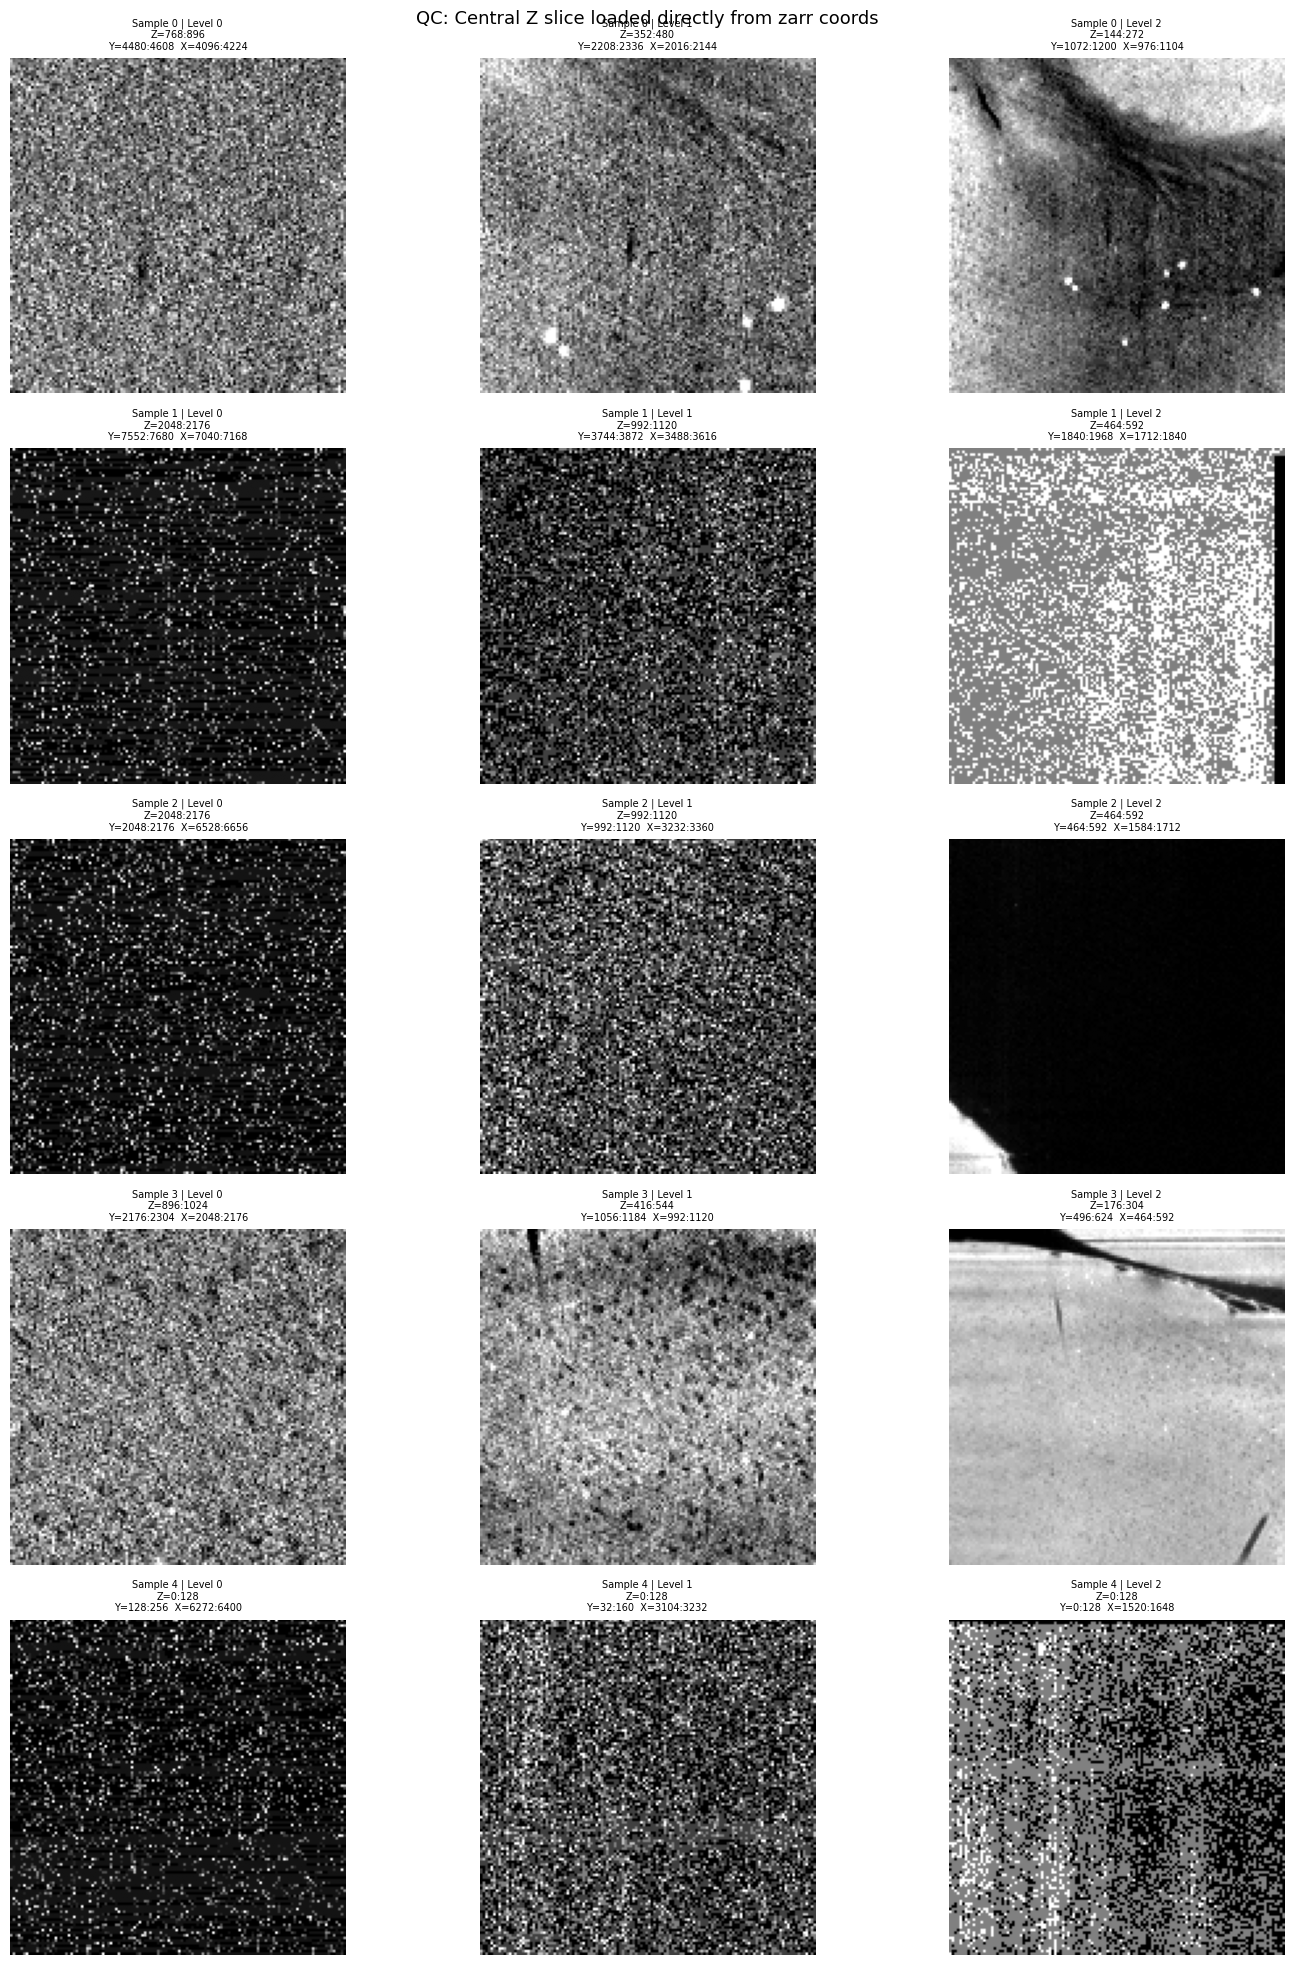

In [6]:
# QC cell: verify coords by loading central slices directly from zarr
# total_coords[i][j] = (z_slice, y_slice, x_slice) for sample i, level index j
# dataset.pyramid_levels = [0, 1, 2] — same ordering as the coord lists

levels = dataset.pyramid_levels
n_samples = len(total_coords)
n_levels = len(levels)

fig, axes = plt.subplots(n_samples, n_levels, figsize=(5 * n_levels, 4 * n_samples))
if n_samples == 1:
    axes = axes[np.newaxis, :]
if n_levels == 1:
    axes = axes[:, np.newaxis]

for i, sample_coords in enumerate(total_coords):
    print("\nSample ", i, " coordinates:", sample_coords)
    for j, lvl in enumerate(levels):
        z_sl, y_sl, x_sl = sample_coords[j]
        arr = dataset.ms_lazy_arrays[lvl]
        print("Lazy array: ", arr, " leve ", lvl)

        # Build full slice (handle 4-D channel arrays)
        if arr.ndim == 4:
            data = arr[slice(None), z_sl, y_sl, x_sl].compute()
            data = np.squeeze(data)
        else:
            data = arr[z_sl, y_sl, x_sl].compute()

        central = data[data.shape[0] // 2]  # central Z slice

        ax = axes[i, j]
        plow, phigh = np.percentile(central, [1, 99])
        ax.imshow(central, cmap="gray", vmin=plow, vmax=phigh)
        ax.set_title(
            f"Sample {i} | Level {lvl}\n"
            f"Z={z_sl.start}:{z_sl.stop}\n"
            f"Y={y_sl.start}:{y_sl.stop}  X={x_sl.start}:{x_sl.stop}",
            fontsize=7,
        )
        ax.set_axis_off()

fig.suptitle("QC: Central Z slice loaded directly from zarr coords", fontsize=13)
plt.tight_layout()
plt.show()